# Clifford Volume Benchmark

This notebook runs the QCMet Clifford Volume benchmark on Aer, evaluates its stabilizer and destabilizer threshold criteria, and compares results across a small noise sweep.

## Import Benchmark and Analysis Dependencies

The setup below finds the repository root so the example also works when opened from a notebook server started in a subdirectory.

In [12]:
import importlib
import sys
from pathlib import Path
import numpy as np

import matplotlib.pyplot as plt
import pandas as pd
from qiskit_aer.noise import NoiseModel, depolarizing_error

workspace_root = Path.cwd()
while not (workspace_root / "pyproject.toml").exists() and workspace_root != workspace_root.parent:
    workspace_root = workspace_root.parent

if not (workspace_root / "pyproject.toml").exists():
    raise FileNotFoundError("Could not locate the QCMet workspace root")

sys.path.insert(0, str(workspace_root))

from qcmet import AerSimulator
from qcmet.benchmarks.circuit_execution_quality_metrics import clifford_volume

CliffordVolume = importlib.reload(clifford_volume).CliffordVolume

## Define `clifford_volume` Benchmark Parameters

Use two qubits and a short depth for a quick local run. Each sampled Clifford generates measurements for the selected stabilizers and destabilizers.

In [ ]:
n_qubits = 20
depth = 4
num_circuits = 4
num_measured_stabilizers = 4
num_shots = 512
seed = 42

## Initialize the Benchmark Runner

The helper keeps benchmark construction and execution settings together for the baseline and sweep.

In [3]:
def run_clifford_volume(
    qubits,
    depth,
    num_circuits,
    noise_probability=0.0,
    num_shots=num_shots,
    seed=seed,
):
    noise_model = NoiseModel()
    if noise_probability:
        error = depolarizing_error(noise_probability, 2)
        noise_model.add_all_qubit_quantum_error(error, ["cx", "swap"])

    benchmark = CliffordVolume(
        qubits=qubits,
        depth=depth,
        num_circuits=num_circuits,
        num_measured_stabilizers=num_measured_stabilizers,
        seed=seed,
    )
    benchmark.generate_circuits()
    benchmark.run(
        device=AerSimulator(
            method="stabilizer",
            noise_model=noise_model,
            seed_simulator=seed,
        ),
        num_shots=num_shots,
    )
    return benchmark.analyze()

## Execute a Single `clifford_volume` Run

Start noiseless. The output includes the individual and average threshold conditions, as well as the overall pass indicator.

In [4]:
baseline_result = run_clifford_volume(
    qubits=n_qubits,
    depth=depth,
    num_circuits=num_circuits,
)

{
    "passes": baseline_result["passes"],
    "average_stabilizers": baseline_result["average_stabilizer_expectation_values"],
    "average_destabilizers": baseline_result[
        "average_destabilizer_expectation_values"
    ],
    "stabilizer_average_pass": baseline_result["stabilizer_average_pass"],
    "destabilizer_average_pass": baseline_result["destabilizer_average_pass"],
}

{'passes': True,
 'average_stabilizers': [1.0, 1.0, 1.0, 1.0],
 'average_destabilizers': [0.0075, 0.005, 0.018000000000000002, 0.0235],
 'stabilizer_average_pass': [True, True, True, True],
 'destabilizer_average_pass': [True, True, True, True]}

## Sweep Problem Sizes and Trial Counts

The sweep varies circuit depth and noise probability while keeping the problem small enough for a local example.

In [45]:
depths = [2, 4, 6, 10, 20, 30, 40, 50]
noise_probabilities = [0.0, 0.01, 0.05]
sweep_results = []

for sweep_depth in depths:
    for noise_probability in noise_probabilities:
        result = run_clifford_volume(
            qubits=n_qubits,
            depth=sweep_depth,
            num_circuits=num_circuits,
            noise_probability=noise_probability,
        )

        stabilizer_means = np.array(
            result["average_stabilizer_expectation_values"], dtype=float
        )
        destabilizer_means = np.array(
            result["average_destabilizer_expectation_values"], dtype=float
        )
        stabilizer_stds = np.array(
            result["average_stabilizer_standard_deviations"], dtype=float
        )
        destabilizer_stds = np.array(
            result["average_destabilizer_standard_deviations"], dtype=float
        )
        stabilizer_individual = np.array(
            result["stabilizer_expectation_values"], dtype=float
        ).ravel()
        destabilizer_individual = np.array(
            result["destabilizer_expectation_values"], dtype=float
        ).ravel()
        stabilizer_individual_stds = np.array(
            result["stabilizer_standard_deviations"], dtype=float
        ).ravel()

        sweep_results.append(
            {
                "qubits": n_qubits,
                "depth": sweep_depth,
                "num_circuits": num_circuits,
                "noise_probability": noise_probability,
                "passes": result["passes"],
                "stabilizer_average": float(np.mean(stabilizer_means)),
                "destabilizer_average": float(np.mean(destabilizer_means)),
                "stabilizer_variance": float(np.mean(stabilizer_stds**2)),
                "destabilizer_variance": float(np.mean(destabilizer_stds**2)),
                "stabilizer_clifford_averages": stabilizer_means.tolist(),
                "destabilizer_clifford_averages": destabilizer_means.tolist(),
                "stabilizer_clifford_stds": stabilizer_stds.tolist(),
                "destabilizer_clifford_stds": destabilizer_stds.tolist(),
                "stabilizer_individual": stabilizer_individual.tolist(),
                "destabilizer_individual": destabilizer_individual.tolist(),
                "stabilizer_individual_std": stabilizer_individual_stds.tolist(),
            }
        )

## Collect Metrics into Tabular Results

A DataFrame makes it straightforward to compare parameter choices or save results for later use.

In [46]:
results_df = pd.DataFrame(sweep_results)
results_df

,qubits,depth,num_circuits,noise_probability,passes,stabilizer_average,destabilizer_average,stabilizer_variance,destabilizer_variance,stabilizer_clifford_averages,destabilizer_clifford_averages,stabilizer_clifford_stds,destabilizer_clifford_stds,stabilizer_individual,destabilizer_individual,stabilizer_individual_std
0,2,2,4,0.00,True,1.000000,-0.002500,0.000000,0.00025,"[1.0, 1.0, 1.0, 1.0]","[0.002, 0.005, 0.003000000000000001, -0.02]","[0.0, 0.0, 0.0, 0.0]","[0.01580515738611925, 0.015810234027363413, 0....","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]","[-0.026, 0.03, 0.016, -0.006, 0.021, -0.015, -...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
1,2,2,4,0.01,True,0.988500,0.016750,0.000006,0.00025,"[1.0, 0.983, 0.9875, 0.9835]","[0.04, -0.0009999999999999992, -0.006500000000...","[0.0, 0.002903015673398958, 0.0024921627153940...","[0.015793788335924982, 0.015807893597820043, 0...","[1.0, 1.0, 0.982, 0.984, 0.987, 0.988, 0.985, ...","[0.065, 0.015, -0.022, 0.02, -0.01, -0.003, 0....","[0.0, 0.0, 0.004223505652890739, 0.00398396787..."
2,2,2,4,0.05,True,0.940625,0.016750,0.000028,0.00025,"[1.0, 0.8945000000000001, 0.954, 0.914]","[0.04, -0.0009999999999999992, -0.006500000000...","[0.0, 0.007068760499550115, 0.0047401213064646...","[0.015793788335924982, 0.015807893597820043, 0...","[1.0, 1.0, 0.895, 0.894, 0.957, 0.951, 0.914, ...","[0.065, 0.015, -0.022, 0.02, -0.01, -0.003, 0....","[0.0, 0.0, 0.009974342083566215, 0.01001908179..."
3,2,4,4,0.00,True,1.000000,0.013500,0.000000,0.00025,"[1.0, 1.0, 1.0, 1.0]","[0.0075, 0.005, 0.018000000000000002, 0.0235]","[0.0, 0.0, 0.0, 0.0]","[0.01581007194797038, 0.015810234027363413, 0....","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]","[0.018, -0.003, 0.016, -0.006, 0.021, 0.015, 0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
4,2,4,4,0.01,True,0.983875,-0.004750,0.000008,0.00025,"[1.0, 0.9635, 0.9875, 0.9844999999999999]","[-0.0145, -0.006, -0.0035, 0.005000000000000001]","[0.0, 0.00423283297567953, 0.00249216271539400...","[0.015809676625408883, 0.01581059771166163, 0....","[1.0, 1.0, 0.964, 0.963, 0.987, 0.988, 0.983, ...","[-0.012, -0.017, 0.002, -0.014, -0.01, 0.003, ...","[0.0, 0.0, 0.005945754788082002, 0.00602623431..."
5,2,4,4,0.05,True,0.917875,-0.004750,0.000038,0.00025,"[1.0, 0.8085, 0.954, 0.909]","[-0.0145, -0.006, -0.0035, 0.005000000000000001]","[0.0, 0.009304535184521578, 0.0047401213064646...","[0.015809676625408883, 0.01581059771166163, 0....","[1.0, 1.0, 0.814, 0.803, 0.957, 0.951, 0.906, ...","[-0.012, -0.017, 0.002, -0.014, -0.01, 0.003, ...","[0.0, 0.0, 0.012988533404507223, 0.01332649616..."
6,2,6,4,0.00,True,1.000000,0.010500,0.000000,0.00025,"[1.0, 1.0, 1.0, 1.0]","[0.02, 0.015, -0.015, 0.022]","[0.0, 0.0, 0.0, 0.0]","[0.015807434959537237, 0.015802009365900274, 0...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]","[0.01, 0.03, -0.016, 0.046, -0.019, -0.011, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
7,2,6,4,0.01,True,0.973250,0.005125,0.000013,0.00025,"[0.984, 0.97, 0.971, 0.968]","[-0.010499999999999999, 0.006500000000000001, ...","[0.0028170463254976845, 0.0038438262187565153,...","[0.01580453653227452, 0.01581060957079138, 0.0...","[0.983, 0.985, 0.97, 0.97, 0.971, 0.971, 0.972...","[0.017, -0.038, -0.001, 0.014, 0.023, 0.014, 0...","[0.004105545030808945, 0.0038584323241440946, ..."
8,2,6,4,0.05,True,0.864250,0.004375,0.000063,0.00025,"[0.9055, 0.8585, 0.8645, 0.8285]","[-0.010499999999999999, 0.0035, 0.0185, 0.006]","[0.006709498863551584, 0.008108198011888956, 0...","[0.01580453653227452, 0.015811131363694376, 0....","[0.906, 0.905, 0.856, 0.861, 0.862, 0.867, 0.8...","[0.017, -0.038, -0.001, 0.008, 0.023, 0.014, 0...","[0.00946477680666586, 0.009512491787118662, 0...."
9,2,10,4,0.00,True,1.000000,0.010750,0.000000,0.00025,"[1.0, 1.0, 1.0, 1.0]","[-0.009999999999999998, 0.0265, 0.003, 0.0235]","[0.0, 0.0, 0.0, 0.0]","[0.015807434959537237, 0.015802511667453372, 0...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]","[0.01, -0.03, 0.047, 0.006, -0.01, 0.016, 0.0

## Plot Performance and Success Metrics

The first panel shows the stabilizer and destabilizer trends; the second shows whether every threshold condition passed.

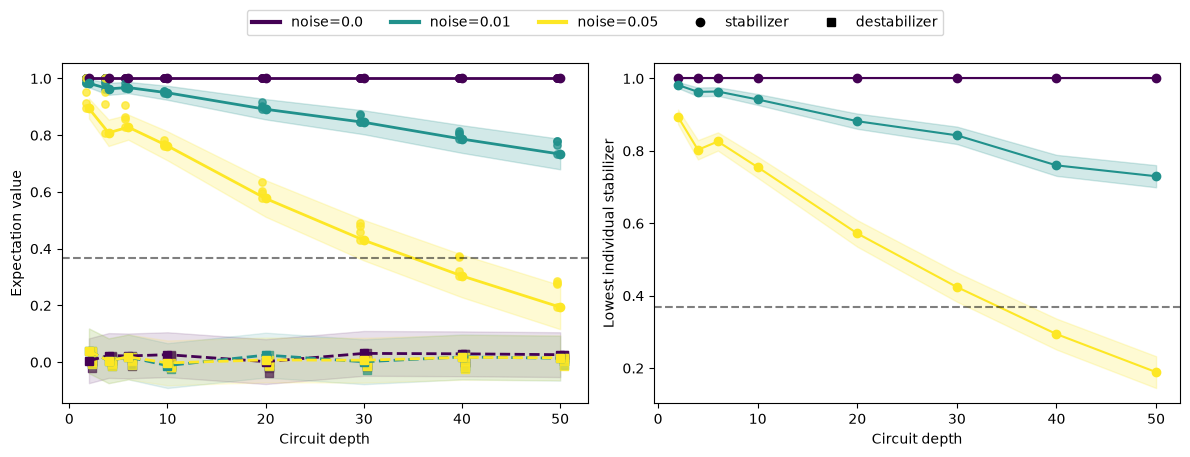

In [51]:
fig, (metric_axis, min_axis) = plt.subplots(1, 2, figsize=(12, 4.5))

noise_levels = sorted(results_df["noise_probability"].unique())
denom = max(len(noise_levels) - 1, 1)
color_map = {
    noise: plt.cm.viridis(index / denom)
    for index, noise in enumerate(noise_levels)
}

for noise_probability in noise_levels:
    group = results_df[results_df["noise_probability"] == noise_probability].sort_values(
        "depth"
    )
    depths_plot = group["depth"].to_numpy(dtype=float)
    color = color_map[noise_probability]

    lowest_stabilizer_averages = []
    lowest_stabilizer_stds = []
    highest_destabilizer_averages = []
    highest_destabilizer_stds = []

    for _, row in group.iterrows():
        depth_value = float(row["depth"])
        stabilizer_averages = np.array(
            row["stabilizer_clifford_averages"], dtype=float
        )
        destabilizer_averages = np.array(
            row["destabilizer_clifford_averages"], dtype=float
        )
        stabilizer_clifford_stds = np.array(
            row["stabilizer_clifford_stds"], dtype=float
        )
        destabilizer_clifford_stds = np.array(
            row["destabilizer_clifford_stds"], dtype=float
        )

        metric_axis.scatter(
            np.full(stabilizer_averages.shape, depth_value - 0.35),
            stabilizer_averages,
            color=color,
            marker="o",
            s=28,
            alpha=0.75,
        )
        metric_axis.scatter(
            np.full(destabilizer_averages.shape, depth_value + 0.35),
            destabilizer_averages,
            color=color,
            marker="s",
            s=28,
            alpha=0.75,
        )

        lowest_index = int(np.argmin(stabilizer_averages))
        lowest_stabilizer_averages.append(float(stabilizer_averages[lowest_index]))
        lowest_stabilizer_stds.append(float(stabilizer_clifford_stds[lowest_index]))

        highest_index = int(np.argmax(destabilizer_averages))
        highest_destabilizer_averages.append(
            float(destabilizer_averages[highest_index])
        )
        highest_destabilizer_stds.append(
            float(destabilizer_clifford_stds[highest_index])
        )

    lowest_stabilizer_averages = np.array(lowest_stabilizer_averages, dtype=float)
    lowest_stabilizer_stds = np.array(lowest_stabilizer_stds, dtype=float)
    metric_axis.plot(
        depths_plot,
        lowest_stabilizer_averages,
        "o-",
        color=color,
        linewidth=2,
    )
    metric_axis.fill_between(
        depths_plot,
        lowest_stabilizer_averages - 5 * lowest_stabilizer_stds,
        lowest_stabilizer_averages + 5 * lowest_stabilizer_stds,
        color=color,
        alpha=0.2,
    )

    highest_destabilizer_averages = np.array(
        highest_destabilizer_averages, dtype=float
    )
    highest_destabilizer_stds = np.array(highest_destabilizer_stds, dtype=float)
    metric_axis.plot(
        depths_plot,
        highest_destabilizer_averages,
        "s--",
        color=color,
        linewidth=2,
    )
    metric_axis.fill_between(
        depths_plot,
        highest_destabilizer_averages - 5 * highest_destabilizer_stds,
        highest_destabilizer_averages + 5 * highest_destabilizer_stds,
        color=color,
        alpha=0.12,
    )

    # pass_axis.plot(
    #     depths_plot,
    #     group["passes"].astype(int),
    #     "o-",
    #     color=color,
    # )

    min_values = []
    min_stds = []
    for _, row in group.iterrows():
        values = np.array(row["stabilizer_individual"], dtype=float)
        stds = np.array(row["stabilizer_individual_std"], dtype=float)
        min_index = int(np.argmin(values))
        min_values.append(float(values[min_index]))
        min_stds.append(float(stds[min_index]))

    min_values = np.array(min_values, dtype=float)
    min_stds = np.array(min_stds, dtype=float)
    min_axis.plot(depths_plot, min_values, "o-", color=color)
    min_axis.fill_between(
        depths_plot,
        min_values - 2 * min_stds,
        min_values + 2 * min_stds,
        color=color,
        alpha=0.2,
    )

metric_axis.set_xlabel("Circuit depth")
metric_axis.set_ylabel("Expectation value")
metric_axis.axhline(y=1 / np.exp(1), linestyle="--", color="k", alpha=0.5)

# pass_axis.set_xlabel("Circuit depth")
# pass_axis.set_ylabel("All criteria pass")
# pass_axis.set_yticks([0, 1], ["No", "Yes"])

min_axis.set_xlabel("Circuit depth")
min_axis.set_ylabel("Lowest individual stabilizer")
min_axis.axhline(y=1 / np.exp(1), linestyle="--", color="k", alpha=0.5)

noise_handles = [
    metric_axis.plot([], [], color=color_map[noise], linewidth=3)[0]
    for noise in noise_levels
]
noise_labels = [f"noise={noise}" for noise in noise_levels]
metric_handles = [
    metric_axis.plot([], [], marker="o", color="black", linestyle="None")[0],
    metric_axis.plot([], [], marker="s", color="black", linestyle="None")[0],
]
metric_labels = ["stabilizer", "destabilizer"]
fig.legend(
    noise_handles + metric_handles,
    noise_labels + metric_labels,
    loc="upper center",
    ncol=5,
    bbox_to_anchor=(0.5, 1.02),
)
fig.tight_layout(rect=(0, 0, 1, 0.92))

## Save Results for Reuse

Save the flattened sweep results alongside the notebook for comparison with other local runs.

In [ ]:
output_path = workspace_root / "examples" / "circuit_benchmarks" / "clifford_volume_results.csv"
results_df.to_csv(output_path, index=False)
output_path

In [34]:
debug_depth = 30
debug_noise = 0.05

debug_result = run_clifford_volume(
    qubits=n_qubits,
    depth=debug_depth,
    num_circuits=num_circuits,
    noise_probability=debug_noise,
)

stabilizer_vals = np.array(debug_result["stabilizer_expectation_values"], dtype=float)
stabilizer_stds = np.array(debug_result["stabilizer_standard_deviations"], dtype=float)

{
    "passes": debug_result["passes"],
    "stabilizer_worst_case_all": bool(np.all(debug_result["stabilizer_worst_case_pass"])),
    "destabilizer_worst_case_all": bool(np.all(debug_result["destabilizer_worst_case_pass"])),
    "stabilizer_average_all": bool(np.all(debug_result["stabilizer_average_pass"])),
    "destabilizer_average_all": bool(np.all(debug_result["destabilizer_average_pass"])),
    "min_single_stabilizer": float(np.min(stabilizer_vals)),
    "min_single_stabilizer_minus_2sigma": float(np.min(stabilizer_vals - 2 * stabilizer_stds)),
    "tau_S": 1 / np.exp(1),
}

{'passes': False,
 'stabilizer_worst_case_all': True,
 'destabilizer_worst_case_all': True,
 'stabilizer_average_all': False,
 'destabilizer_average_all': True,
 'min_single_stabilizer': 0.424,
 'min_single_stabilizer_minus_2sigma': 0.3834975556293203,
 'tau_S': np.float64(0.36787944117144233)}